# Potts model

In [1]:
import numpy as np

from collections import deque

from matplotlib import pyplot as plt

## **Step 1:** Define Q states with values 1, 2, ..., Q.

In [2]:
Q_n = 10
Q = np.arange(1,Q_n+1)
delta_cronecker = np.diag([1 for i in range(Q_n)])

## **Step 2:** Initialize the starting configuration:
- Cold: All spins set to 1.
- Random: Each spin randomly assigned a value from 1 to Q with uniform distribution.

In [3]:
grid_size = 10

grid_cold = np.ones((grid_size, grid_size))
grid_rand = np.random.choice(Q, size=(grid_size,grid_size), replace=True)

print(grid_rand)

[[ 4 10  1  4  6  9  2  1  2  2]
 [ 4  6  1  2  2  5  1  7  5  9]
 [ 5  4  8  9  8  3  8  8  6  8]
 [ 1  8  7  1  9  6 10  2  6  2]
 [ 5  4 10  8  6  3 10  7  1  1]
 [ 8  2  8  6  7  8  5  5  5  9]
 [ 5  1  2  2  5  4  1  7  6  4]
 [ 9  2  2  3  3  8  8 10 10 10]
 [ 4  3  8 10  3  6 10  2  6  7]
 [ 6  3  8  5  8  8  2  4  1  9]]


## **Step 3**: Run the Metropolis and Wolff cluster algorithms for the Potts model, similar to the Ising model.

For spin flips, propose a new, different random value from 1 to Q.

Formulas to compute energy and magnetization:

+ Energy: $$ E= - \sum_{<i,j>} \delta_{s_i s_j}$$
where $<i,j>$ denotes neighboring pairs.

+ Magnetization:
$$ M = \dfrac{Q}{Q-1} \bigl( \dfrac{N_{max}}{N^2} - \dfrac{1}{Q}\bigr)$$
where $N$ is the lattice size, $N_{max}$  is the count of the most frequent spin state in the lattice.

### Func

In [4]:
def get_total_energy_system(grid):
    right_neighbours = np.roll(grid, 1, axis=1)
    down_neighbours = np.roll(grid, 1, axis=0)

    energy = -np.sum(grid == right_neighbours) - np.sum(grid == down_neighbours)

    return energy

get_total_energy_system(grid_rand)

-22

In [5]:
def get_total_magnetization_system(grid):
    _N = len(grid)
    _grid_counter = np.bincount(grid.astype(int).flatten(), minlength=Q_n+1)[1:]
    _N_max = np.max(_grid_counter)

    return (Q_n / (Q_n-1)) * ((_N_max/(_N*_N)) - (1/Q_n))

get_total_magnetization_system(grid_rand)

0.06666666666666667

In [6]:
def plot_stats(mag,tot_en, sus, betas, title_model, critical_beta=None, grid_names = None):
    mag_arr = np.array(mag)
    en_arr = np.array(tot_en)
    sus_arr = np.array(sus)
    betas = betas

    labels = grid_names
    if grid_names is None:
        labels = []
        for i, _ in enumerate(mag_arr):
            labels.append(str(f"Grid {i}"))

    colors = ['#d62728', '#1f77b4', '#2ca02c']

    fig, axs = plt.subplots(3, 2, figsize=(18, 14), sharex=True)

    for i in range(2):
        # --- Row 1: Magnetization ---
        axs[0, i].plot(betas, mag_arr[:, i], 'o-', color=colors[i], markersize=4)
        axs[0, i].set_title(f"Magnetization ({labels[i]})", fontweight='bold')
        if critical_beta is not None:
            axs[0, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[0, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[0, i].set_ylabel(r"$\langle |M| \rangle$")

        # --- Row 2: Total Energy ---
        axs[1, i].plot(betas, en_arr[:, i], 's-', color=colors[i], markersize=4)
        axs[1, i].set_title(f"Total Energy ({labels[i]})", fontweight='bold')
        if critical_beta is not None:
            axs[1, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[1, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[1, i].set_ylabel("Energy (E)")

        # --- Row 3: Susceptibility ---
        axs[2, i].plot(betas, sus_arr[:, i], '^-', color=colors[i], markersize=4)
        axs[2, i].set_title(f"Susceptibility ({labels[i]})", fontweight='bold')
        axs[2, i].set_xlabel(r"Inverse Temperature $\beta$")
        if critical_beta is not None:
            axs[2, i].axvline(x=critical_beta, color='orange', linestyle='--', alpha=0.5)
        axs[2, i].grid(True, linestyle=':', alpha=0.6)
        if i == 0: axs[2, i].set_ylabel(r"Susceptibility $\chi$")

    axs[0, 0].plot([], [], color='orange', linestyle='--', label=f'Critical Beta ({critical_beta:.3f})')
    fig.legend(loc='upper center', ncol=1, frameon=False)

    plt.suptitle(f"Potts Model({title_model}): Statistical Properties vs. Inverse Temperature", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### MCMC

In [7]:
def local_spin_energy_change(grid, i, j):
    N = len(grid)
    old_spin = grid[i, j]
    _Q = [i for i in range(1,Q_n+1) if i != old_spin]

    new_spin = np.random.choice(_Q, size=1, replace=True).item()

    neighbours = (
        grid[(i-1)%N,j],
        grid[(i+1)%N,j],
        grid[i,(j-1)%N],
        grid[i,(j+1)%N]
    )

    old_energy = -sum(1 for n in neighbours if n == old_spin)
    new_energy = -sum(1 for n in neighbours if n == new_spin)

    delta_e = new_energy - old_energy

    return delta_e, new_spin

print(local_spin_energy_change(grid_rand, 3, 6), grid_rand[3,6])

(1, 1) 10


In [8]:
def monte_carlo_metropolis_step(grid, beta):
    def __boltzmann_probability(delta_e, beta):
        return np.exp(-beta * delta_e)

    N = len(grid)

    for _ in range(N * N):
        random_index = np.random.randint(N * N)
        x_ind = random_index // N
        y_ind = random_index % N

        delta_e, new_spin = local_spin_energy_change(grid, x_ind, y_ind)

        # Logika Metropolis
        if delta_e <= 0:
            grid[x_ind, y_ind] = new_spin
        else:
            if np.random.random() <= __boltzmann_probability(delta_e, beta):
                grid[x_ind, y_ind] = new_spin

    return grid

### Wolff

In [9]:
def wolff_step(grid, beta, J=1.0):
    N = len(grid)
    random_index = np.random.randint(N * N)
    x_seed = random_index // N
    y_seed = random_index % N

    seed_spin = grid[x_seed, y_seed]
    cluster = {(x_seed, y_seed)}
    queue = deque([(x_seed, y_seed)])


    # accept prob
    acc_prob = 1.0 - np.exp(-1*beta*J)

    # neighbours checks
    while len(queue) > 0:
        x, y = queue.popleft()

        neighbours = (
            ((x-1)%N,y),
            ((x+1)%N,y),
            (x,(y-1)%N),
            (x,(y+1)%N)
        )

        # check neighbours
        for x_n, y_n in neighbours:
            # if in cluster or opposite spin -> we skip
            if ((x_n,y_n) not in cluster) and (grid[x_n,y_n] == seed_spin):
                if np.random.random() < acc_prob:
                    queue.append((x_n,y_n))
                    cluster.add((x_n,y_n))

    # cluster switching the spin
    _Q = [i for i in range(1,Q_n+1) if i != seed_spin]
    new_spin = np.random.choice(_Q, size=1, replace=True).item()
    for x, y in cluster:
        grid[x, y] = new_spin

    return grid

### Simulation loop

In [10]:
def ising_simulation_with_stats(grid, step_func, beta, steps, burn_in_steps=0, verbose=False):
    active_steps = steps - burn_in_steps
    if active_steps <= 0:
        print("[WARNING] burn_in_steps is more or equal than the number of steps")
        return grid, 0, 0, 0

    _grid = grid.copy()
    _sum_mag = 0.0
    _sum_mag_sq = 0.0
    _sum_en = 0.0
    N_sq = len(grid)**2

    bar = range(steps)

    for i in bar:
        _grid = step_func(_grid, beta)

        if i >= burn_in_steps:
            current_m = get_total_magnetization_system(_grid)
            _sum_mag += current_m
            _sum_mag_sq += current_m**2

            current_e = get_total_energy_system(_grid)
            _sum_en += current_e

    _avg_mag = _sum_mag / active_steps
    _avg_mag_sq = _sum_mag_sq / active_steps
    _total_en = _sum_en / active_steps

    _susceptibility = beta * N_sq * (_avg_mag_sq - (_avg_mag**2))

    if verbose:
        print("Total magnetism (avg): ", _avg_mag,
              "Total energy (avg): ", _total_en,
              "Total susceptibility: ", _susceptibility, sep='\n')

    return _grid, _avg_mag, _total_en, _susceptibility

# Task
Plot magnetization and energy of Potts model as a function of $\beta$ near $\beta_c = \ln(1+ \sqrt{Q})$ using Metropolis and Wolff cluster.

In [11]:
import time
import numpy as np
from tqdm import tqdm
from copy import deepcopy

def run_complete_simulation(step_func, betas, initial_grids, steps, burn_in):
    results = {
        'mag': [],
        'en': [],
        'sus': [],
        'times': []
    }

    for beta in tqdm(betas, desc=f"Symulacja: {step_func.__name__}"):
        beta_mag, beta_en, beta_sus = [], [], []

        start_t = time.time()

        for i, grid in enumerate(initial_grids):
            _, m, e, s = ising_simulation_with_stats(
                grid=deepcopy(grid),
                step_func=step_func,
                beta=beta,
                steps=steps,
                burn_in_steps=burn_in
            )

            beta_mag.append(m)
            beta_en.append(e)
            beta_sus.append(s)

            if i == 0:
                results['times'].append(time.time() - start_t)

        results['mag'].append(beta_mag)
        results['en'].append(beta_en)
        results['sus'].append(beta_sus)

    results['mag'] = np.array(results['mag'])
    results['en'] = np.array(results['en'])
    results['sus'] = np.array(results['sus'])
    results['times'] = np.array(results['times'])

    return results

In [12]:
# Wspólne parametry
critical_point = np.log(1+np.sqrt(Q_n))
betas = np.arange(min(critical_point-1, 0), critical_point+1, 0.1)
grids = [grid_cold, grid_rand]

# 1. Symulacja Metropolis
stats_metropolis = run_complete_simulation(
    step_func=monte_carlo_metropolis_step,
    betas=betas,
    initial_grids=grids,
    steps=3000,
    burn_in=500
)

# 2. Symulacja Wolff
stats_wolff = run_complete_simulation(
    step_func=wolff_step,
    betas=betas,
    initial_grids=grids,
    steps=3000,
    burn_in=500
)

Symulacja: wolff_step: 100%|██████████| 25/25 [00:09<00:00,  2.58it/s]


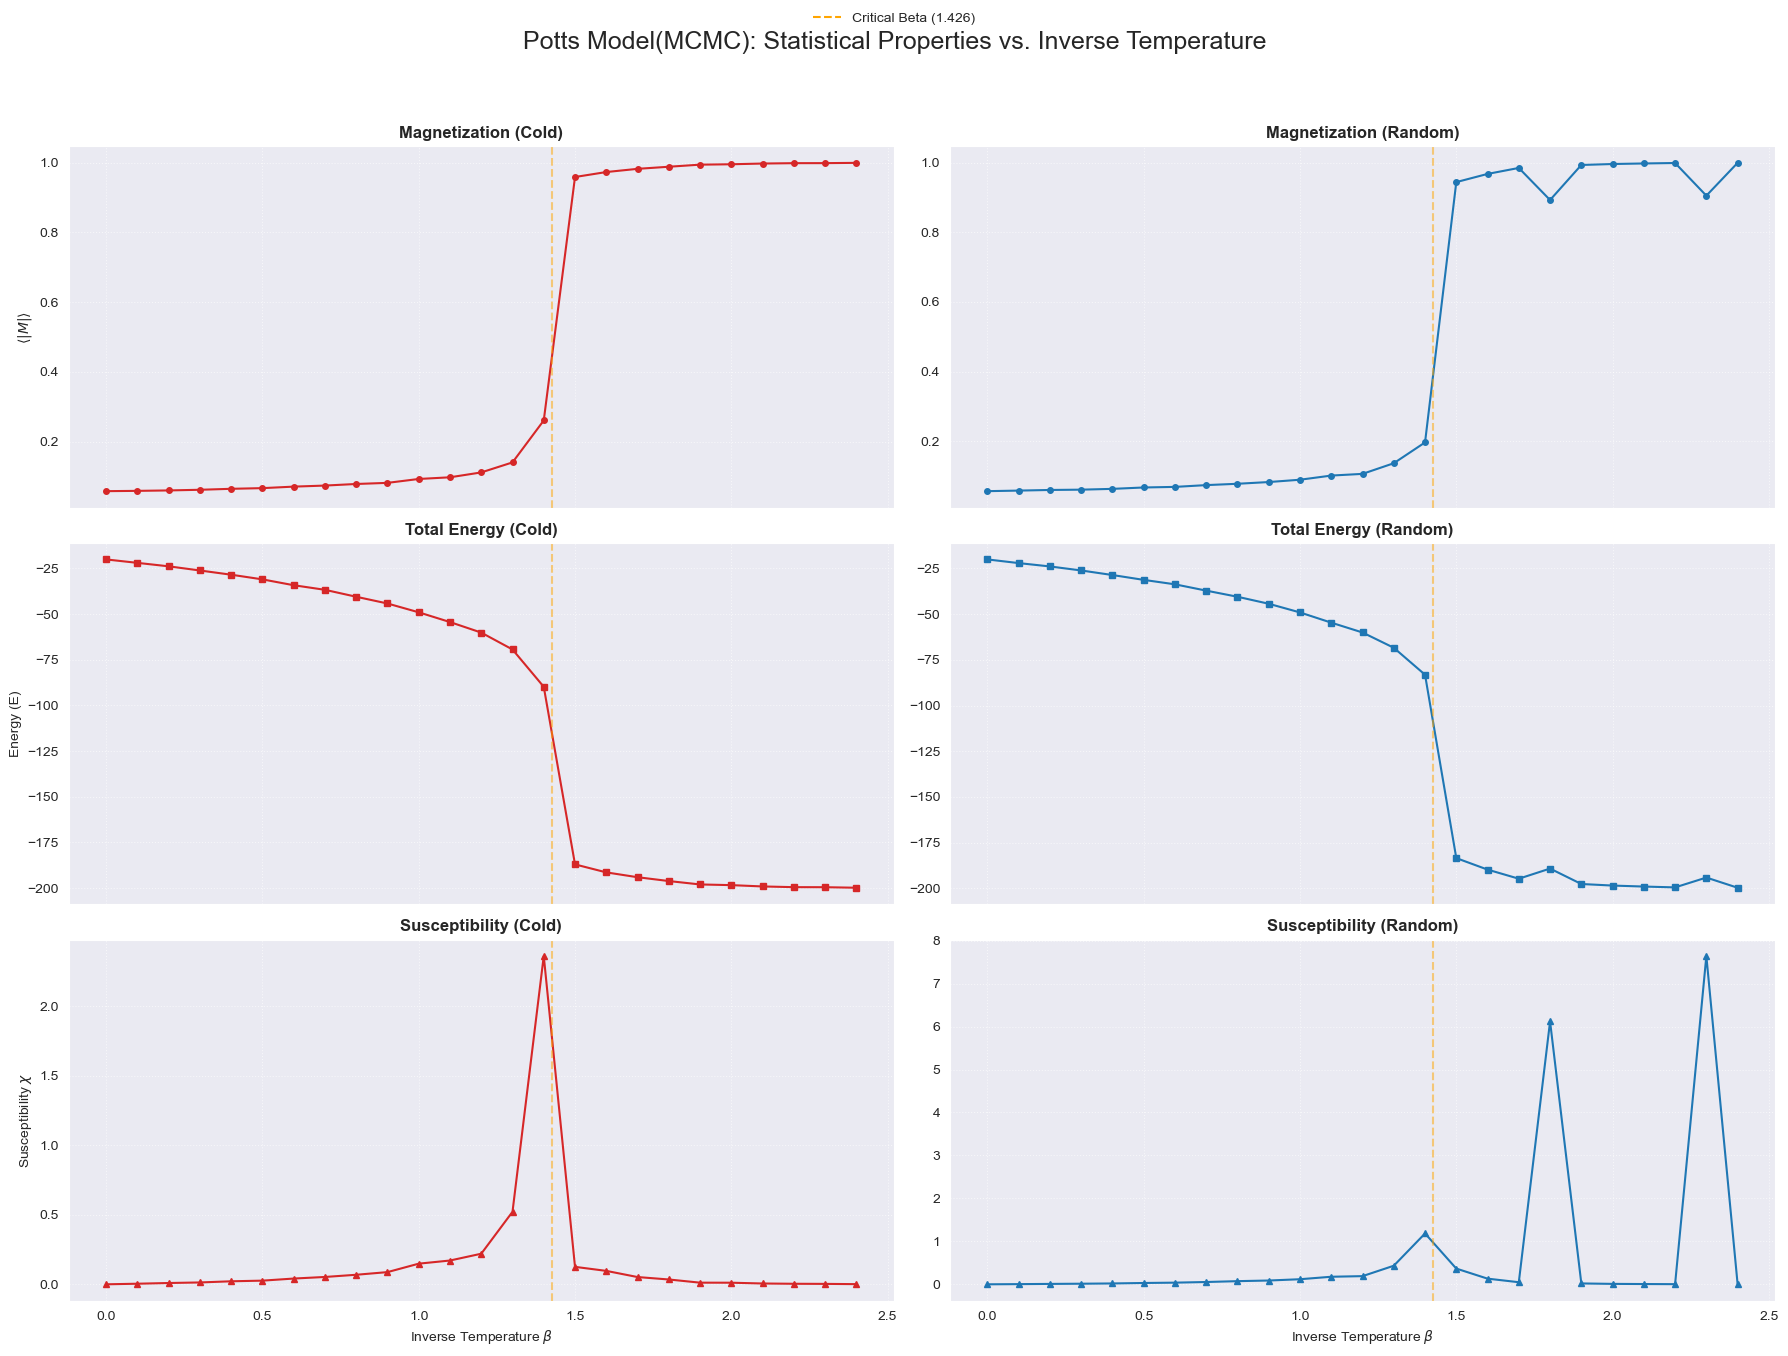

In [13]:
plot_stats(mag = stats_metropolis['mag'], tot_en = stats_metropolis['en'], sus = stats_metropolis['sus'], betas=betas,title_model="MCMC", critical_beta = np.log(1+np.sqrt(Q_n)), grid_names=["Cold", "Random"])

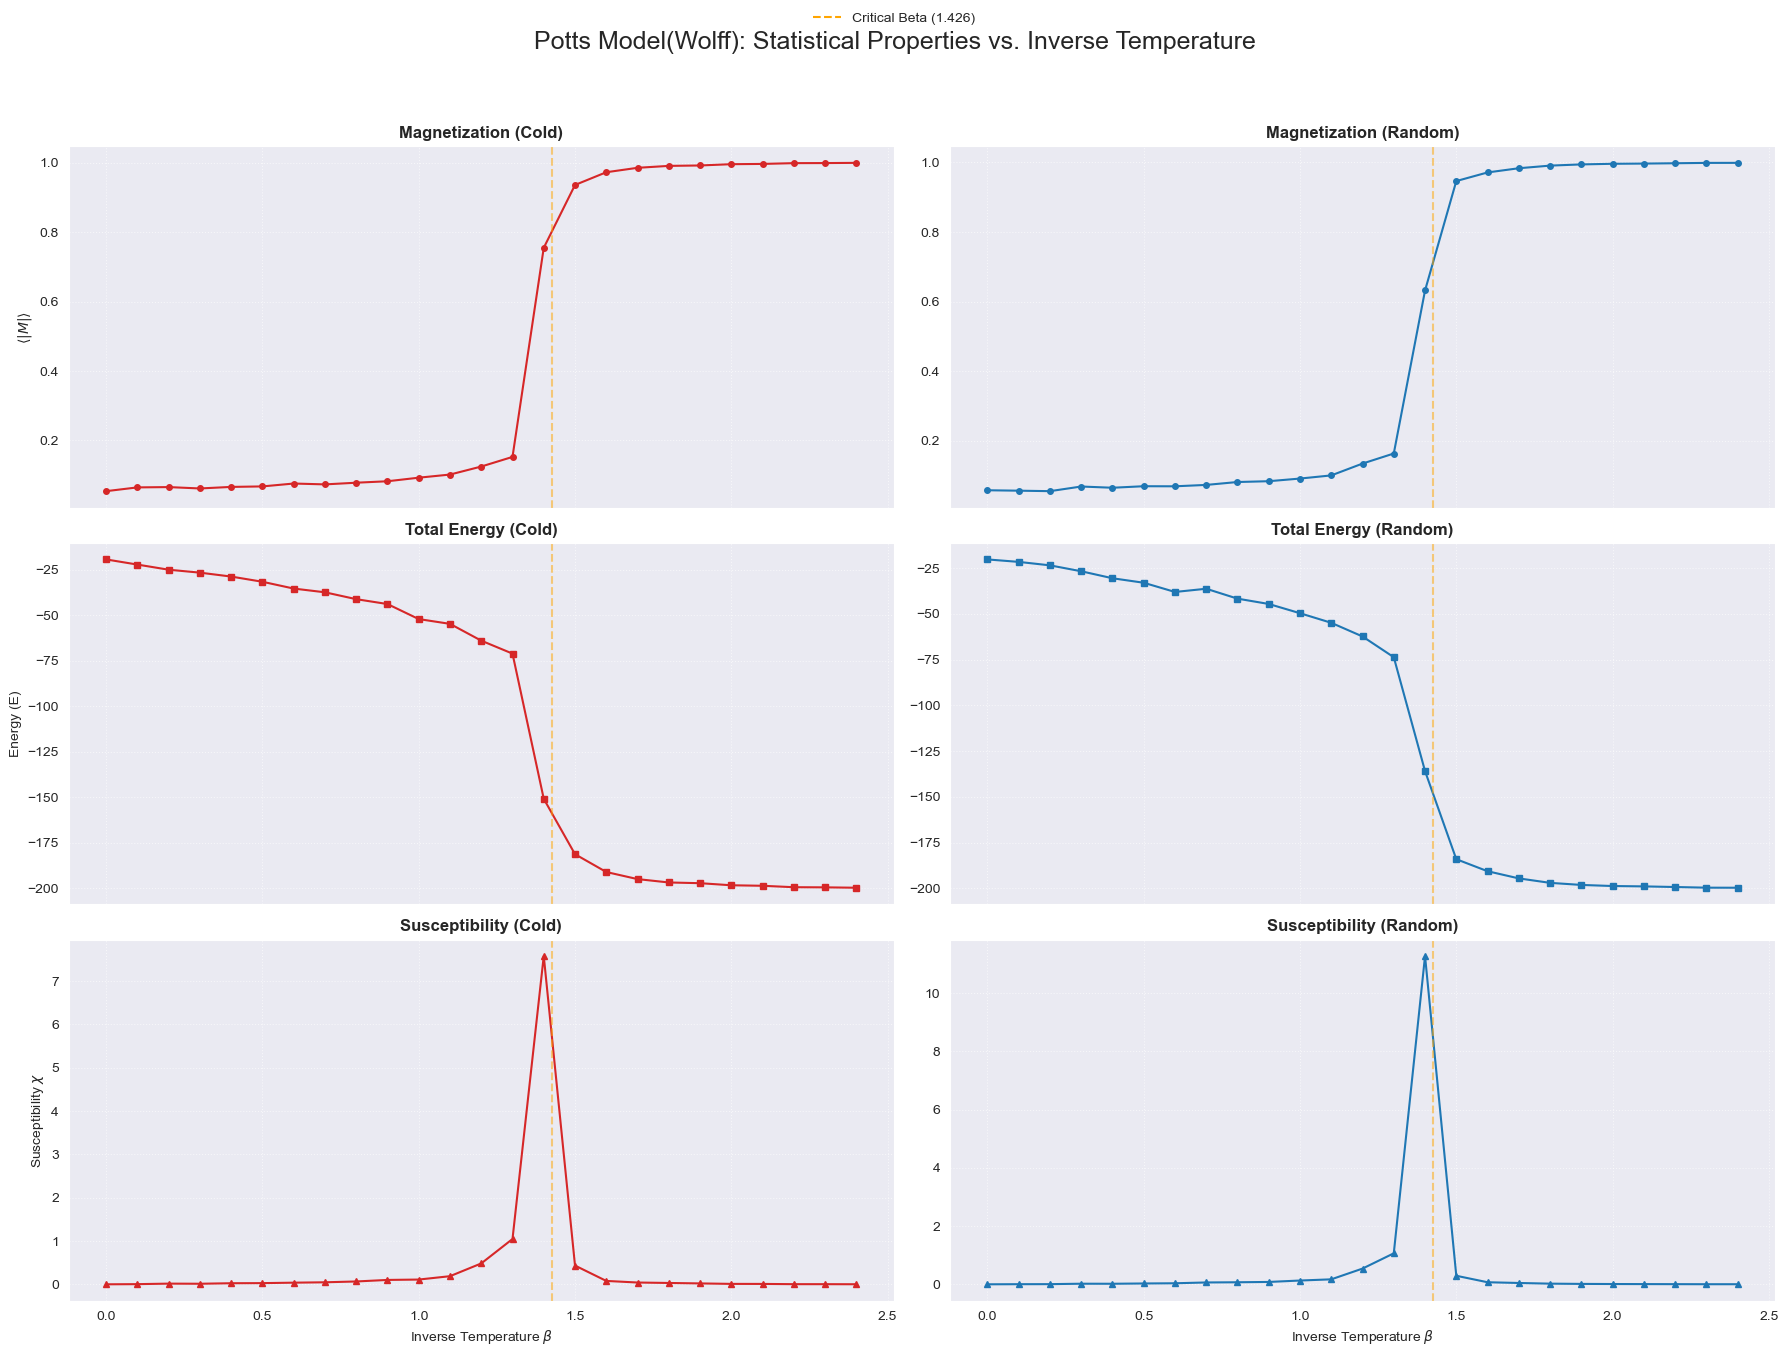

In [14]:
plot_stats(mag = stats_wolff['mag'], tot_en = stats_wolff['en'], sus = stats_wolff['sus'], betas=betas, title_model="Wolff",  critical_beta = np.log(1+np.sqrt(Q_n)), grid_names=["Cold", "Random"])

> Comment: Potts Model - Metropolis & Wolff Cluster Algorithm
> Modifications from Ising to Potts
>
> Both algorithms were adapted from the Ising model by replacing the binary spin flip with a random choice of a new state from the remaining $Q-1$ states. The energy calculation was changed from spin products to the Kronecker delta - contributing $-1$ for each pair of equal neighbouring spins. Magnetization was replaced with the order parameter $M = \frac{Q}{Q-1}\left(\frac{N_{max}}{N^2} - \frac{1}{Q}\right)$, which maps to 0 in the disordered phase and 1 in the fully ordered phase.
>
> For the Wolff algorithm specifically, the bond acceptance probability was corrected to $1 - e^{-\beta J}$ (without the factor of 2 present in the Ising case), since the energy contribution per equal-spin pair is 1 rather than $2J$.
>
> Observations
>
> The simulations were run for $Q = 10$, $N = 10$ near $\beta_c = \ln(1 + \sqrt{Q})$, with both cold (all spins = 1) and hot (random) initializations.
>
> Both algorithms correctly reproduce the first-order phase transition at $\beta_c$. Magnetization jumps sharply from ~0 to ~1, energy drops discontinuously, and susceptibility shows a sharp peak - all consistent with a first-order transition expected for $Q > 4$.
>
> The Wolff algorithm produces a noticeably cleaner transition with less noise around $\beta_c$, which is expected - by flipping entire clusters it tunnels between phases more efficiently than single-spin Metropolis updates. The cold and hot starts converge to the same values away from $\beta_c$, with the largest discrepancies visible precisely at the transition point due to metastability.